# RAG
by use of __LangChain__ and __Ollama__

__RAG (Retrieval-Augmented Generation)__ is an approach of combining the classic information retrieval techniques with modern generative technologies. It is introduced by Meta as a solution for improving the accuracy of LLM applications by enabling them with access to new and dynamically extendable information, that exists in external, for them, sources.<br>

In RAG, the developer can collect a set of documents, relevant to the domain, to pre-process them independently from the LLM processing, and at the next step, to integrate the RAG pre-processing outcome with the input to the LLM application.<br>

The advantages of involving RAG in the process of NLU are the enabling of individualisation and better adaptation to the tasks, keeping consistency of the LLM by providing it with the new available facts, and therefore ensuring higher reliability of the operations results.<br>

see more: tdi@https://innotechspace.dk/holodeck/glossary-of-terms/

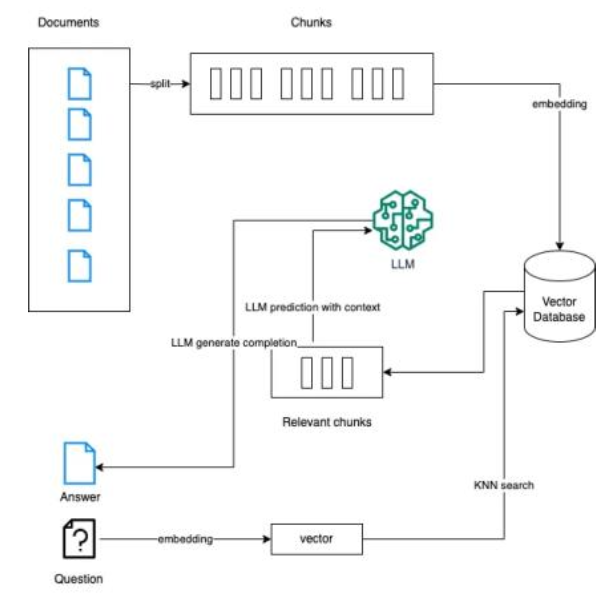

image source: https://medium.com/@kelvin.lu.au/what-we-need-to-know-before-adopting-a-vector-database-85e137570fbb

This demo example extends the implementation of semantic search, seen earlier. The resultsd of the semantic search will be associated with the user's prompt and passed to LLM together with it, supplying it with new additional, context-dependent information for better grounding of the LLMs work.

## Install Libraries

In [ ]:
#!pip install --upgrade langchain

In [ ]:
#!pip install -qU langchain-community

In [ ]:
#!pip install -qU langchain-ollama

In [ ]:
#!pip install -U langchain-text-splitters

In [ ]:
#!pip install -qU langchain-chroma

In [ ]:
#!pip install beautifulsoup4

In [ ]:
#!pip install pydentic

In [ ]:
#!pip install -qU  youtube-transcript-api

In [ ]:
#!pip install -qU  pytube

In [ ]:
# !ollama serve

In [ ]:
!pip install -r ./requirements.txt

In [ ]:
from langchain_community.docstore.document import Document
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.document_loaders import YoutubeLoader 
from langchain_community.document_loaders import PyPDFLoader
from langchain_community.document_loaders import Docx2txtLoader
from langchain_community.document_loaders import TextLoader
from langchain_community.document_loaders import DirectoryLoader
from langchain_community.document_loaders import WikipediaLoader
# from langchain.document_loaders.blob_loaders.youtube_audio import YoutubeAudioLoader
from langchain_community.document_loaders.csv_loader import CSVLoader
# from langchain_core.documents import Document

In [ ]:
# for text pre-processing
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.vectorstores import InMemoryVectorStore

In [ ]:
# for help of open-source LLMs
from langchain_ollama.llms import OllamaLLM
from langchain_core.prompts import ChatPromptTemplate

In [ ]:
import os, pprint
from typing import List

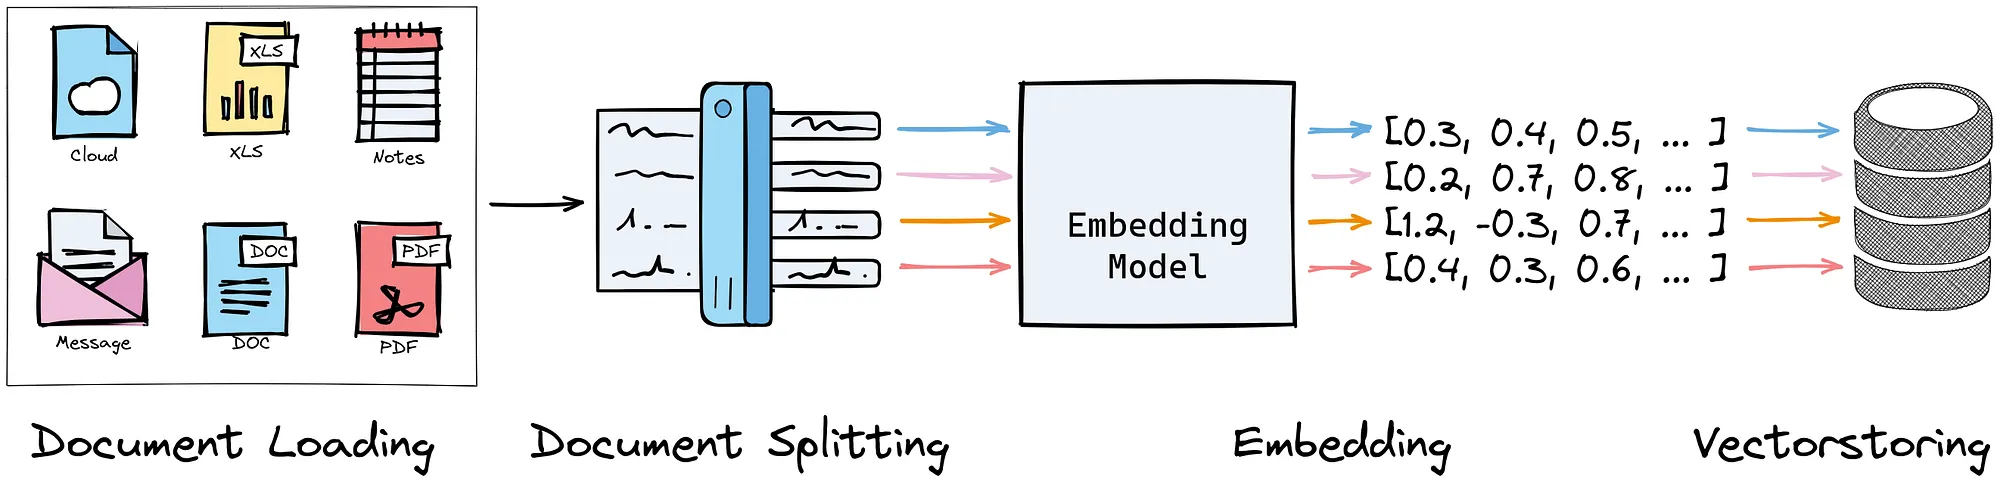

## Load Documents

In [ ]:
!pwd

In [ ]:
import tools
from tools import readers, utils
from tools.readers import *

In [ ]:
def load_docs(url):
    if 'http' in url:
            if 'youtube' in url:
                docs = loadyoutube.loadYoutube(url);
            elif 'wikipedia' in url:
                docs = loadwiki.loadWiki(url);
            else:
                docs = loadweb.loadWeb(url);
    else:
            docs = loadfile.loadFile(url);
    return docs

In [ ]:
documents = []
url = ''
finished = False

while not finished:
    url = input('Enter the location of your source: ')   
    finished = url == 'end'
    if finished: break;
    docs = load_docs(url)
    documents.extend(docs)


In [ ]:
# for test
# /Users/tdi/Documents/GitHub/foxdocs/dat-bi/Data/what-is-rag.pdf
# https://www.youtube.com/watch?v=Y08Nn23o_mY&t=69s
# https://en.wikipedia.org/wiki/Retrieval-augmented_generation

In [ ]:
len(documents)

In [ ]:
documents[6].metadata

In [ ]:
documents[6].page_content

In [ ]:
def save_uploaded(documents, file_path):
    try:
        with open(file_path, 'w') as f:
            for docs in documents:
                f.write(f"{docs}\n")
        return True
    except Exception as e:
        print(f"Error occurred while writing the file: {e}")
        return False

In [ ]:
save_uploaded(documents, './data/temp_save.resources')

## Split the Documents

In [ ]:
# load lib
from langchain_text_splitters import RecursiveCharacterTextSplitter

In [ ]:
# parse the collected text
def split_docs(documents):
    text_splitter = RecursiveCharacterTextSplitter(
        chunk_size=500,
        chunk_overlap=50,
        add_start_index=True
    )
    chunks = text_splitter.split_documents(documents)
    # texts = text_splitter.split_text(documents)
    return chunks


In [ ]:
chunks = split_docs(documents)
len(chunks)

In [ ]:
chunks[10].metadata

## Embed and Store the Documents
We encode (embed) the text chunks into digital vectors (an array of multiple numbers, representing the importance of the text components), then we store the vectors in a vector database.<br>
We can use either external or in-memory database.

We need a pretrained AI model for encoding the embeddings. We work with open-source models from Ollama or HuggingFace.

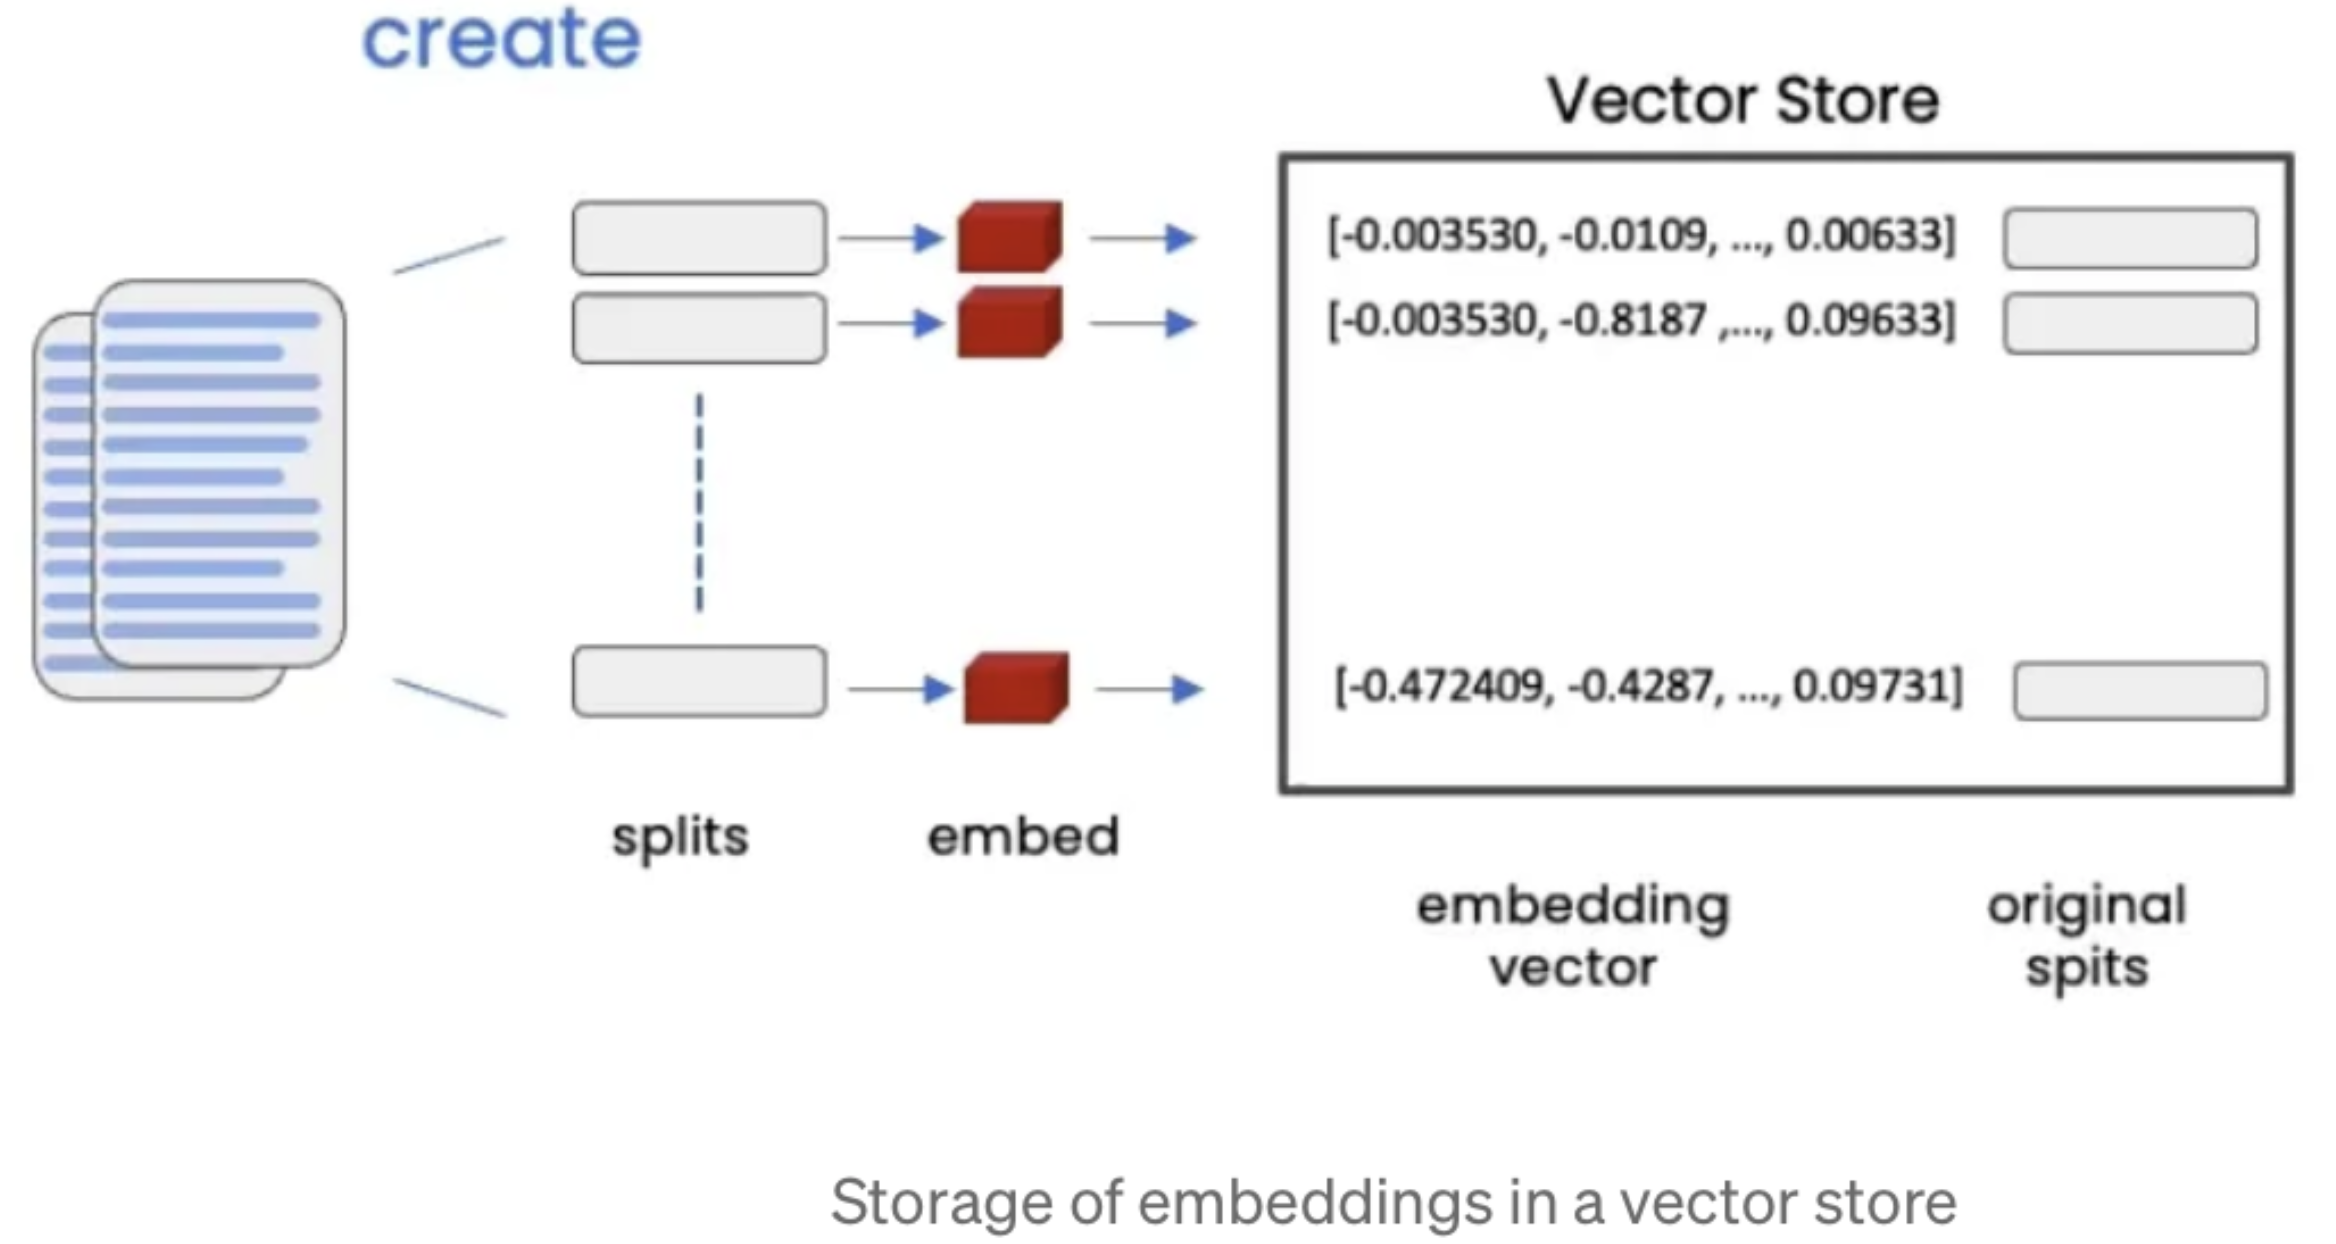

In [ ]:
from langchain_chroma import Chroma
from uuid import uuid4

In [ ]:
from langchain_ollama import OllamaEmbeddings

In [ ]:
!ollama list

In [ ]:
# choose Ollama model for embedding
model = "embeddinggemma:300m"
embeddings = OllamaEmbeddings(model=model)

In [ ]:
# vector_store = InMemoryVectorStore(embeddings)

In [ ]:
vector_store = Chroma(
    collection_name="rag",
    embedding_function=embeddings,
    persist_directory="./data/chroma_db"
)

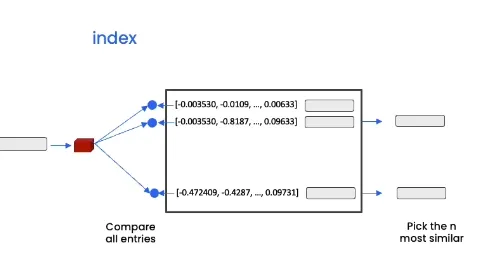

In [ ]:
def store_docs(documents):
    # create random indeces
    uuids = [str(uuid4()) for _ in range(len(documents))]
    # store the documents
    vector_store.add_documents(documents=documents, ids=uuids)
    return

In [ ]:
store_docs(chunks)

## Retrieve Data

In [ ]:
def retrieve_docs(query, k):
    retrieved = vector_store.similarity_search(query, k)
    return retrieved

In [ ]:
def retrieve_docs_score(query, k):
    retrieved = vector_store.similarity_search_with_score(query, k)
    return retrieved

In [ ]:
q = "RAG reduces the hallucinations of the LLM."

In [ ]:
# similarity search test
results = retrieve_docs(q, 3)

In [ ]:
for res in results:
    print(f"* [{res.page_content}] [{res.metadata}]")

In [ ]:
# similarity search test
results = retrieve_docs_score(q, 3)

In [ ]:
for res, score in results:
    print(f"* [SIM={score:3f}][{res.metadata}]")

## Augment LLM Generation

In [ ]:
!ollama list

In [ ]:
llm = OllamaLLM(model = "qwen3.5:9b")
# llm = OllamaLLM(model = 'llama3.2:latest')

In [ ]:
# A template for a dialoque
template = """
You are an assistant for BI/AI learning tasks. 
Use the following pieces of retrieved context to augment the LLM in answering the question. 
If you don't know the answer, just say that you don't know. 
Use three sentences maximum and keep the answer concise.
Question: {question} 
Context: {context} 
Answer:
"""

In [ ]:
def answer_question(question, documents):
    context = "\n\n".join([doc.page_content for doc in documents])
    prompt = ChatPromptTemplate.from_template(template)
    chain = prompt | llm
    return chain.invoke({"question": question, "context": context})

## Apply RAG

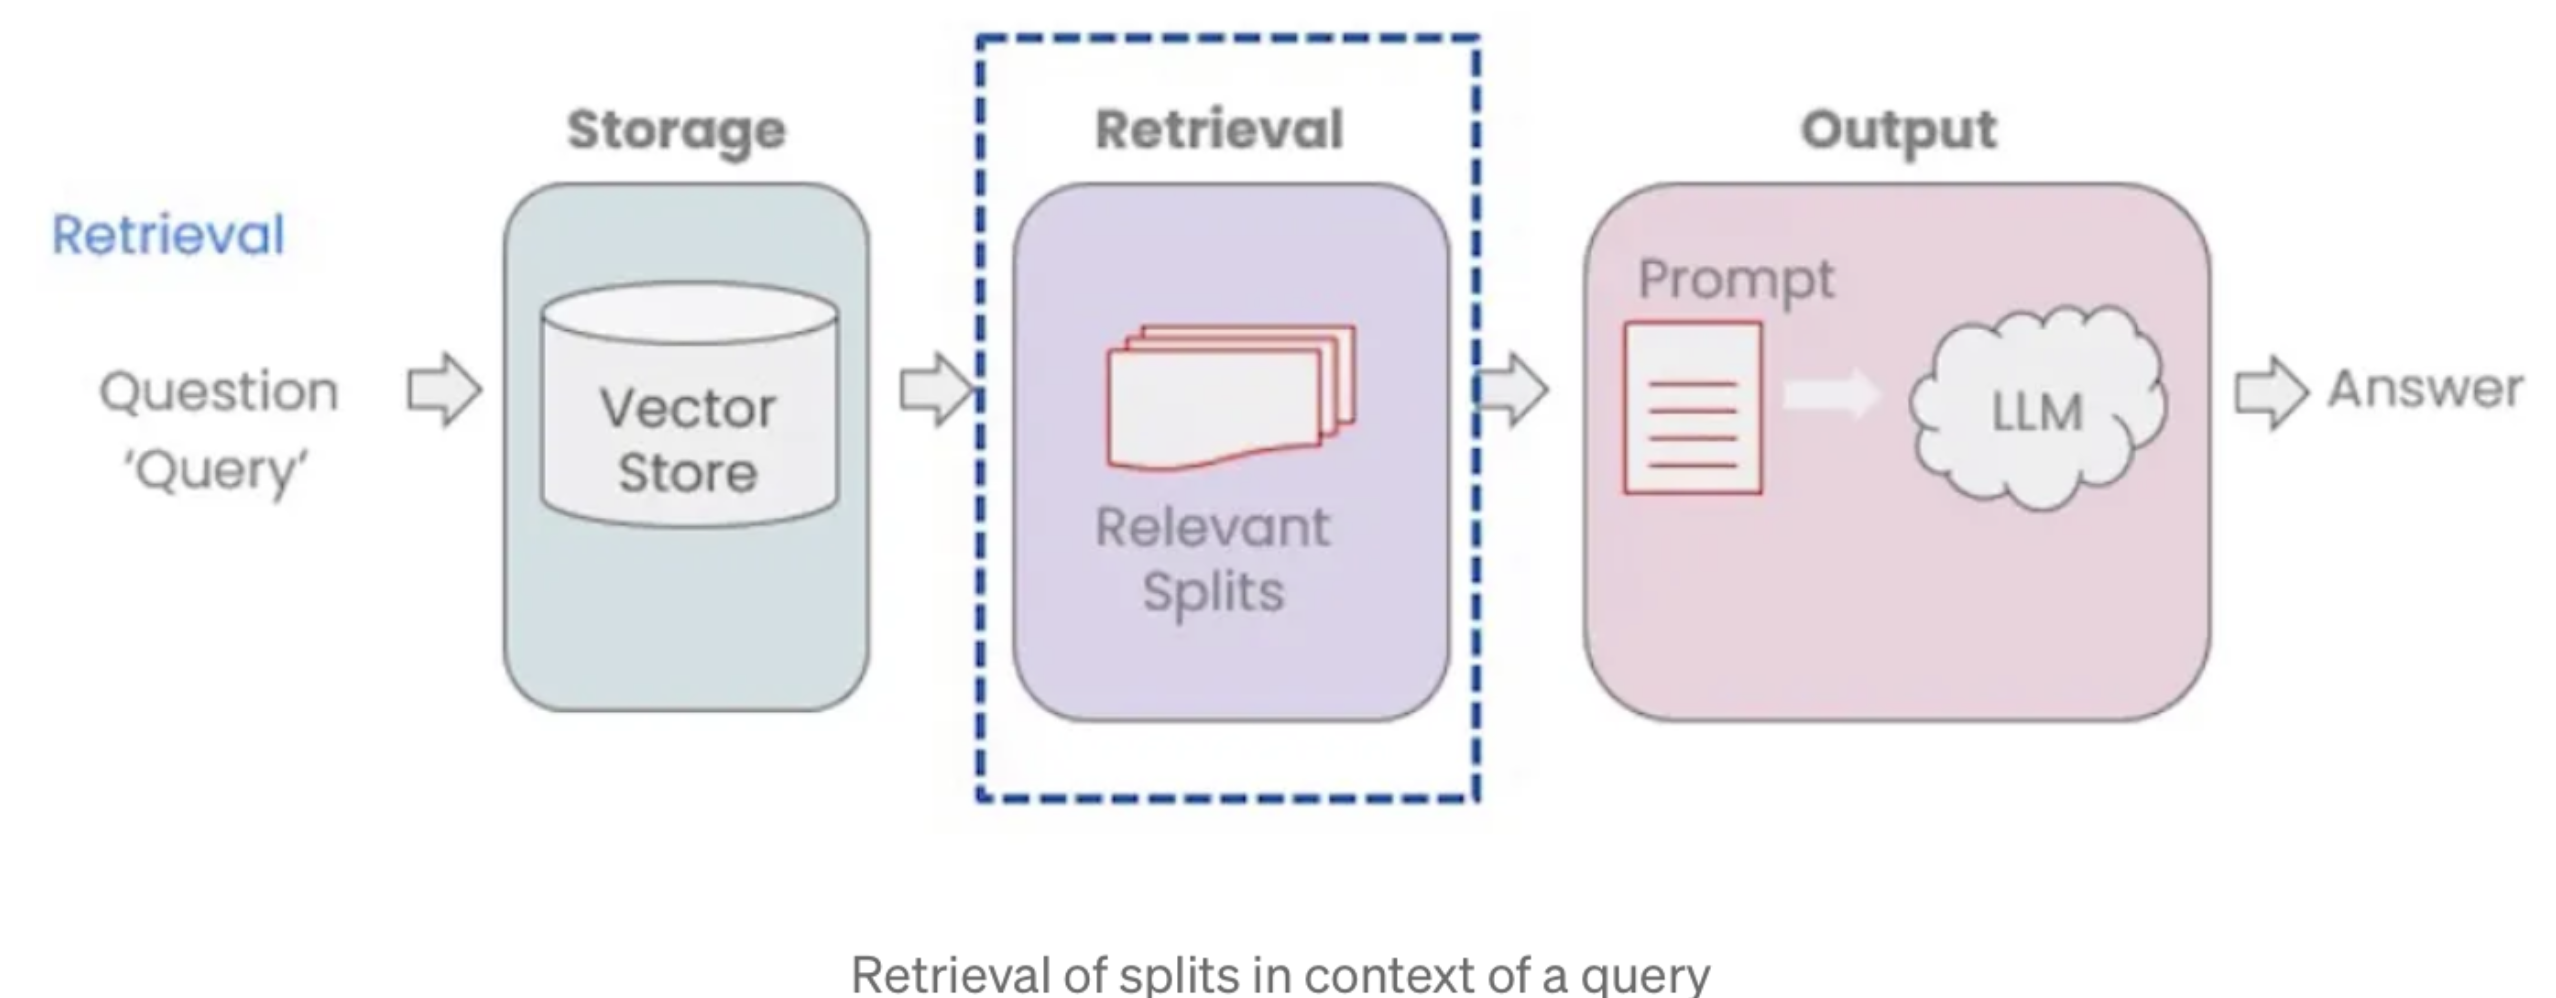

In [ ]:
question = 'What is RAG?'

In [ ]:
# send the user's question to the vector db for retrieving the relevant context
retrieved = retrieve_docs(question, 2)

In [ ]:
retrieved[0].metadata

In [ ]:
answer = answer_question(question, retrieved)

In [ ]:
answer

In [ ]:
question = "Which data is stored in a vector database?"

In [ ]:
question = "Which teams won their football matches yesterday?"

In [ ]:
related_documents = retrieve_docs(question, 1)  

In [ ]:
answer = answer_question(question, related_documents)

In [ ]:
answer

In [ ]:
answer